# (Pseudobulk) Differential Expression analysis using DESEq2

In this notebook, we will describe how to perform a powerful differential expression analysis (DEA) using DESeq2. We will use for illustration the Astrocyte pseudobulk data from SEA-AD brain interogating effect of APOE4 genotype. 

The data are available for 2 different brain region (MTG and DLPFC), 
we will start by analyzed DLPFC region.

To perform DEA, we need to start with a clean / homogeneous dataset and identify the putative confounding factors or technical covariates suspectible to influence results of our DEA. 
To do that, 2 critical steps are required before DEA : 

**I) the QC/selection of both genes and samples**, and **II) the covariates analysis**. 

### Set up

In [ ]:
out<-'../outputs/01-SEAAD_data/pseudobulk_deseq2/'
dir.create(out)
source('../../../utils/r_utils.R') 
source('../../../utils/pca_utils.R')
library(DESeq2)
library(edgeR)
library(sctransform)

### Load data and metadata

In [7]:
# load data 
pseudo_count<-fread('../outputs/01-SEAAD_data/DLPFC/pseudobulk_main_cell_type/Astro.csv.gz')
head(pseudo_count)

#transform to matrix
mat<-as.matrix(data.frame(pseudo_count,row.names = 'gene_id'))



gene_id,H18.30.002,H19.30.001,H19.30.002,H19.33.004,H20.33.001,H20.33.002,H20.33.004,H20.33.005,H20.33.008,⋯,H21.33.037,H21.33.038,H21.33.040,H21.33.041,H21.33.042,H21.33.043,H21.33.044,H21.33.045,H21.33.046,H21.33.047
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
MIR1302-2HG,0,0,0,0,0,1,0,0,0,⋯,0,0,2,0,0,0,0,0,0,0
FAM138A,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
OR4F5,0,0,0,0,0,0,0,0,0,⋯,1,0,0,0,0,0,0,0,0,0
AL627309.1,8,5,4,21,7,14,14,27,2,⋯,6,10,35,10,18,13,4,10,20,1
AL627309.3,0,0,0,3,1,2,1,0,0,⋯,1,0,5,2,2,2,0,0,0,0
AL627309.2,1,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [10]:
mtd<-fread('../outputs/01-SEAAD_data/DLPFC/pseudobulk_main_cell_type/Astro_metadata.csv.gz')
head(mtd)

Donor.ID,main_cell_type,PMI,sample_quantity_count,expc_cell_capture,pcr_cycles,percent_cdna_longer_than_400bp,amplified_quantity_ng,library_input_ng,avg_size_bp,⋯,outlier.ethnicity,outlier.cellular.status,outlier.cellprop,outlier,original_cell_type_name,UMIs.outlier,cell.outlier,donor.outlier,pass.threshold.n.cells,outlier.n.cells
<chr>,<chr>,<dbl>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,⋯,<lgl>,<lgl>,<lgl>,<lgl>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>
H18.30.002,Astro,NA,16000,9280,12,0.972,353.54350,353.54350,498,⋯,NA,FALSE,FALSE,TRUE,Astrocyte,FALSE,FALSE,TRUE,TRUE,FALSE
H19.30.001,Astro,NA,16000,9280,12,1.022,68.29078,68.29078,474,⋯,NA,FALSE,FALSE,TRUE,Astrocyte,FALSE,FALSE,TRUE,TRUE,FALSE
H19.30.002,Astro,NA,16000,9280,12,0.993,283.69367,283.69367,448,⋯,NA,FALSE,FALSE,TRUE,Astrocyte,FALSE,FALSE,TRUE,TRUE,FALSE
H19.33.004,Astro,8.133333,15775,10254,12,0.928,42.89403,42.89403,458,⋯,FALSE,FALSE,FALSE,FALSE,Astrocyte,FALSE,FALSE,FALSE,TRUE,FALSE
H20.33.001,Astro,7.700000,15925,10351,12,0.982,98.85236,98.85236,480,⋯,FALSE,FALSE,FALSE,FALSE,Astrocyte,FALSE,FALSE,FALSE,TRUE,FALSE
H20.33.002,Astro,4.333333,16102,10466,12,0.940,54.50899,54.50899,454,⋯,FALSE,FALSE,FALSE,FALSE,Astrocyte,FALSE,FALSE,FALSE,TRUE,FALSE


## I) QC of samples and genes
We remove samples if flagged as outliers in previous QC / exploratory analysis (See [SEAAD_QC.ipynb](SEAAD_QC.ipynb) ).  
Here, all donors with clinical or cellular abnormalities are excluded, as well as pseudobulk samples derived from less than 50 cell (flag `outlier.n.cells`)

In [13]:
#remove samples if flagged as outliers (See QC script) 
cat('outliers stats:')
mtd[(outlier)][,.(Donor.ID,Cognitive.Status,outlier.clinical.status,ethnicity,outlier.ethnicity,cell_prop_dev_pc1,outlier.cellprop,n.cells,outlier.n.cells)]
mtdf<-mtd[!(outlier|outlier.n.cells)]
nrow(mtdf)#71

to_keep<-mtdf$Donor.ID 
cat(length(to_keep),' samples kept after QC\n')
mat<-mat[,to_keep]

#genes signicantly express (thr= 1CPM) in less than 10% of sample are removed
isexpr <- rowSums(cpm(mat)>1) >= 0.1 * ncol(mat)
cat(sum(isexpr),' genes kept after QC\n')

matf <- mat[isexpr,]


outliers stats:

Donor.ID,Cognitive.Status,outlier.clinical.status,ethnicity,outlier.ethnicity,cell_prop_dev_pc1,outlier.cellprop,n.cells,outlier.n.cells
<chr>,<chr>,<lgl>,<chr>,<lgl>,<dbl>,<lgl>,<int>,<lgl>
H18.30.002,Reference,TRUE,,NA,0.30701321,FALSE,1421,FALSE
H19.30.001,Reference,TRUE,,NA,0.12909622,FALSE,963,FALSE
H19.30.002,Reference,TRUE,,NA,0.33456092,FALSE,1077,FALSE
H20.33.017,Dementia,FALSE,White,FALSE,0.05290414,FALSE,1826,FALSE
H20.33.028,Dementia,FALSE,White,FALSE,-8.81276335,TRUE,2249,FALSE
H20.33.029,Dementia,TRUE,Asian,TRUE,0.51764804,FALSE,1008,FALSE
H20.33.036,No dementia,FALSE,White,FALSE,-3.42025714,TRUE,1698,FALSE
H20.33.038,Dementia,FALSE,White,FALSE,-3.07531318,TRUE,1300,FALSE
H21.33.003,No dementia,TRUE,Asian,TRUE,1.00870983,FALSE,1649,FALSE


[1] 70

70  samples kept after QC
21522  genes kept after QC


## II) Influence of covariates 


### Association with our factor of interest
We first have a look to see if there is putative confounding factor with our our factor of interest (here apoe4. 
We are doing for them linear regression analysis between APOE4 and others clinical covariates.
Let's first transform as numerical all covariates which can be


In [19]:
## transform as numerical all covariates which can be
mtdf[,braak.num:=as.numeric(as.factor(Braak))]
unique(mtdf[,.(braak.num,Braak)])[order(braak.num)]
mtdf[,thal_score:=as.numeric(factor(Thal))]
unique(mtdf[,.(Thal,thal_score)])[order(thal_score)]
mtdf[,atherosclerosis:=as.numeric(factor(Atherosclerosis,levels = c('None','Mild','Moderate','Severe')))]
unique(mtdf[,.(Atherosclerosis,atherosclerosis)])[order(atherosclerosis)]


braak.num,Braak
<dbl>,<chr>
1,Braak 0
2,Braak II
3,Braak III
4,Braak IV
5,Braak V
6,Braak VI


Thal,thal_score
<chr>,<dbl>
Thal 0,1
Thal 1,2
Thal 2,3
Thal 3,4
Thal 4,5
Thal 5,6


Atherosclerosis,atherosclerosis
<chr>,<dbl>
None,1
Mild,2
Moderate,3
Severe,4


Also we have to levels correctly the categorical covariate (put as first position the 'reference')

In [ ]:
# levels correctly categorical factor
mtdf[,Cognitive.Status:=factor(Cognitive.Status,levels = c('No dementia','Dementia'))] #reference is 'No dementia', so put in first positon,
mtdf[,APOE4.Status:=factor(APOE4.Status,levels = c('N','Y'))]
mtdf[,Sex:=factor(Sex,levels = c('Female','Male'))]

Then choose all putative confounding factor /covariates susceptible to influence gene expression.
We split them depending if they are categorical or numerical in order to perform appropriate linear regression

In [20]:

covs_to_check<-list(categorical=c('batch_vendor_name','method',
                                  'Cognitive.Status','Sex','APOE4.Status'),
                    nums=c('avg.pct.mt.ct','n.cells','med.umis.per.cell',
                           'med.genes.per.cell','library_input_ng','pcr_cycles',
                           'PMI','age_at_death_num','Brain.pH','braak.num',
                           'Fresh.Brain.Weight','thal_score','atherosclerosis'))


We can start study their association with APOE4 status

In [22]:
factor_of_int<-'APOE4.Status'

res_cor_fctr<-rbindlist(lapply(setdiff(covs_to_check$nums,factor_of_int), function(f){
  mod<-lm(unlist(mtdf[,lapply(.SD, as.numeric),.SDcols=factor_of_int])~unlist(mtdf[,..f]))
  summstats<-summary(mod)
  data.table(factor=f,
             p=summstats$coefficients[2,4],
             beta=summstats$coefficients[2,1],
             R2=summstats$adj.r.squared)
}))
res_cor_fctr[p<0.05] 



factor,p,beta,R2
<chr>,<dbl>,<dbl>,<dbl>
braak.num,1.099716e-02,0.1254817,0.0779743
thal_score,2.137446e-05,0.1402737,0.2234900


Braak stage and Thal are associated with APOE status, which was expected regarding the impact of APOE4 on AD neuropathogenesis.



### Influence of the covariates on the gene expression
We then perform a PCA to assess  influence of each covariates in the transcriptome variance. These covariates contributing to the main sources of variance in our data have to be integrated in our model to take into account these important factors of variability.

To study that, we first normalized and scale the data using a variance stabilizing transformation (vst) designed for UMI count and single cell data. see this [this article](https://genomebiology.biomedcentral.com/articles/10.1186/s13059-019-1874-1). T
We then perform PCA on this UMIs depth normalized matrix.

In [23]:
#normalized the data using a variance stabilizing transformation (vst)
matf_norm_scaled <- sctransform::vst(matf)$y #y is pearson residual, so already scaled data

pca<-RunPca(matf_norm_scaled,scale = F,center = F)



Calculating cell attributes from input UMI matrix: log_umi

Variance stabilizing transformation of count matrix of size 21522 by 70

Model formula is y ~ log_umi

Get Negative Binomial regression parameters per gene

Using 2000 genes, 70 cells



  |======================================================================| 100%


Second step: Get residuals using fitted parameters for 21522 genes



  |======================================================================| 100%


Calculating gene attributes

Wall clock passed: Time difference of 4.239761 secs

removing 0 features (21522remaining) because missing value or without variance



Let's check the influence of each covariates in the 2 first PCs

The legacy packages maptools, rgdal, and rgeos, underpinning the sp package,
which was just loaded, will retire in October 2023.
Please refer to R-spatial evolution reports for details, especially
https://r-spatial.org/r/2023/05/15/evolution4.html.
It may be desirable to make the sf package available;
package maintainers should consider adding sf to Suggests:.
The sp package is now running under evolution status 2
     (status 2 uses the sf package in place of rgdal)



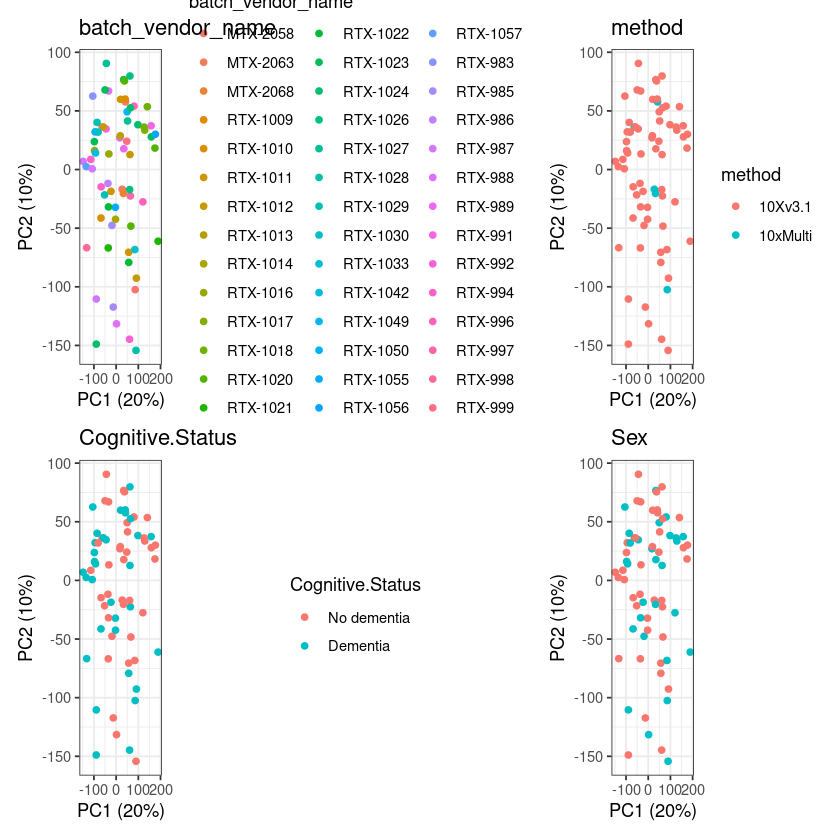

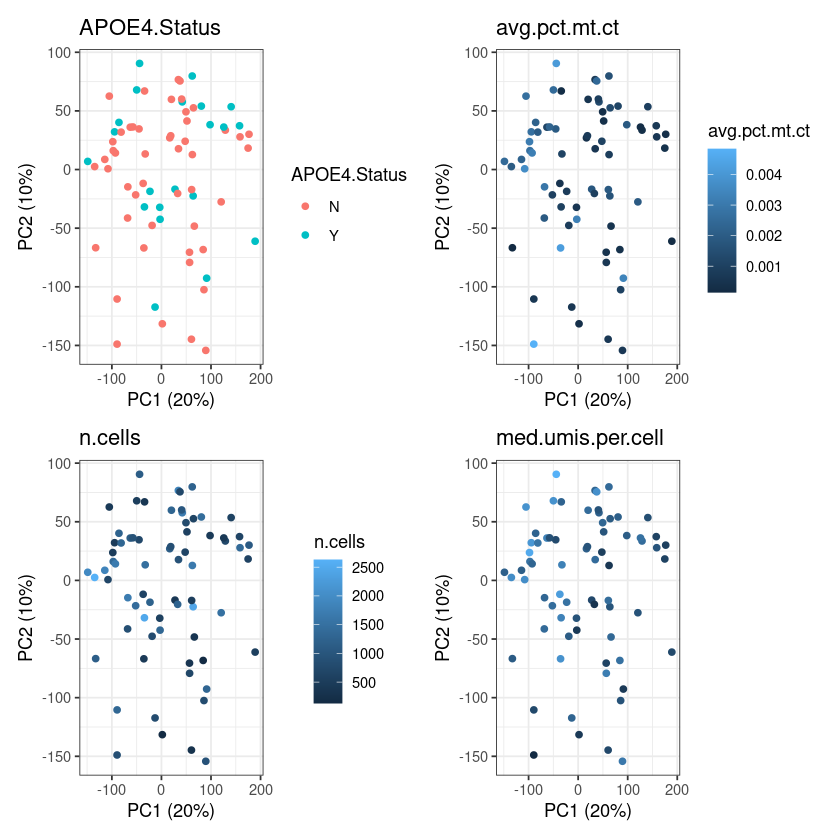

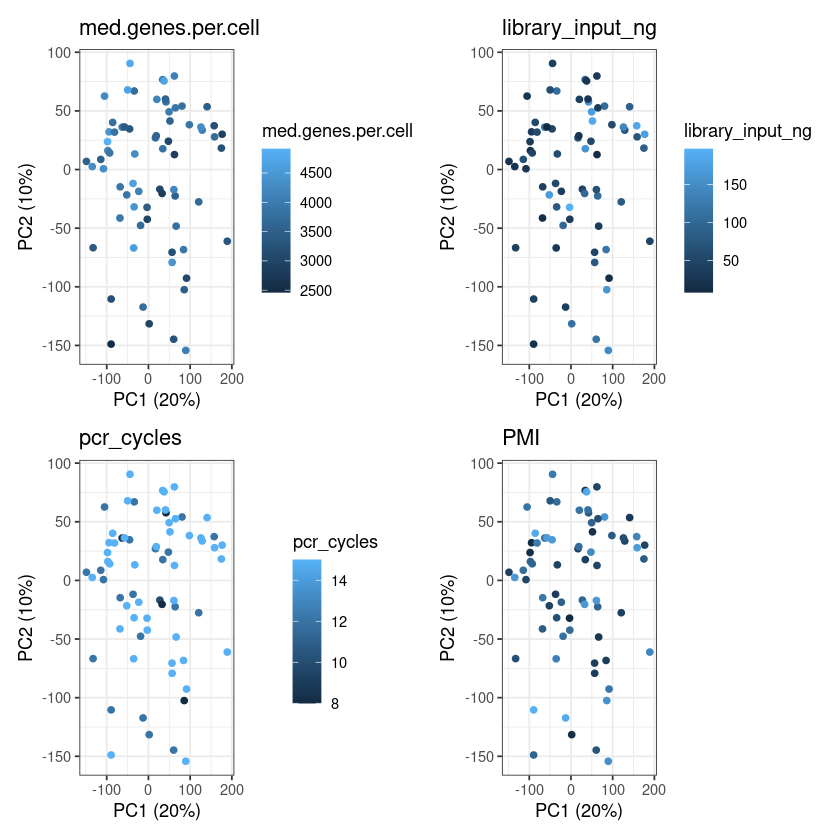

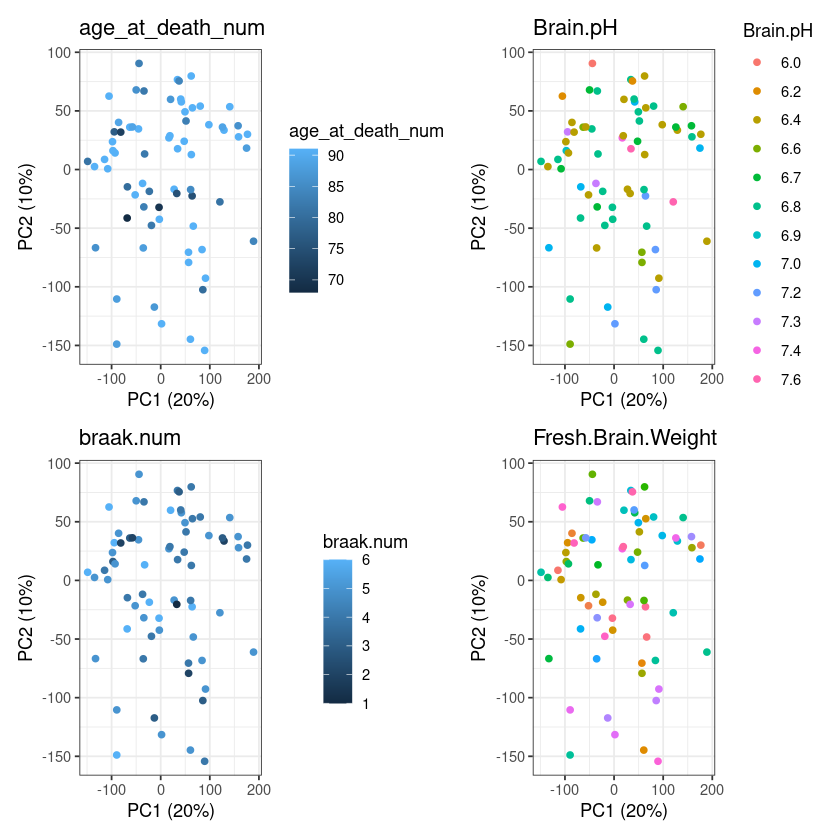

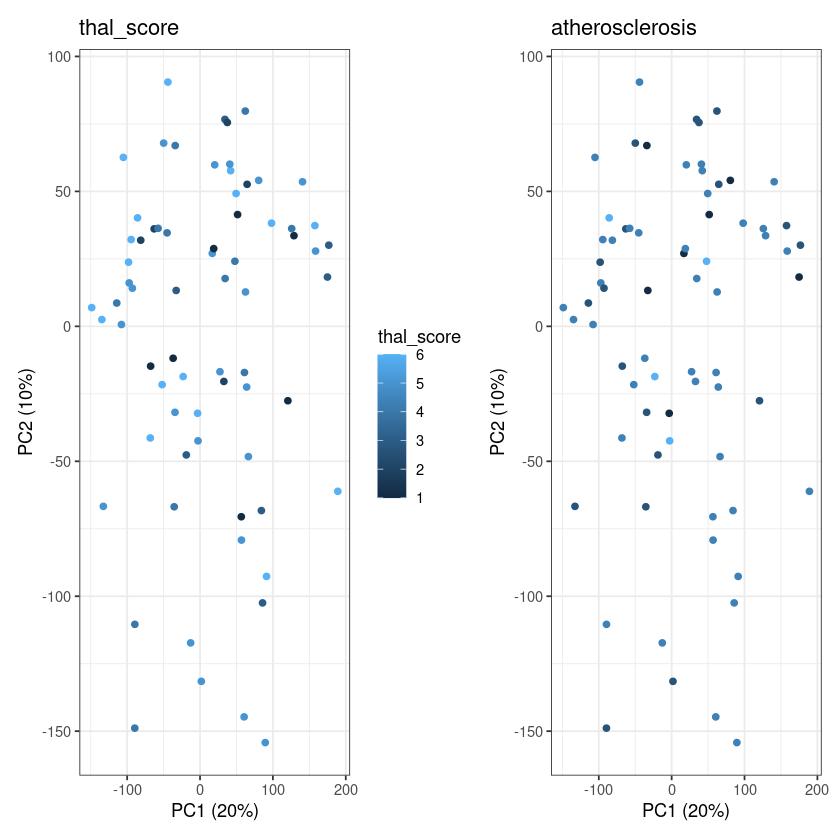

In [26]:
for(i in seq.int(from = 1,to = length(unlist(covs_to_check)),by=4)){
  covs_to_plot<-head(unlist(covs_to_check)[i:length(unlist(covs_to_check))],4)
  print(PcaPlot(pca,mtdf,
          group.by =covs_to_plot ,
          sample_col = 'Donor.ID',ncol=2))
  
  #ggsave(fp(out,ps('pca_astrocyte_pseudobulk_covs_',paste(covs_to_plot,collapse = '_'),'.png')),width = 7,height = 6)
  
}

No obvious association can be found here.
To have an overall and stastical results of these association between covariates and PCs we can use the `CorrelCovarPCs()` from sourced `pca_utils.R` script.  
This function used the same linear modeling strategy than previously used for factor of interest-covariates analysis. 
We than plot heatmap for association (-log10(pvalue)) between PCs and covariates

Loading required package: pheatmap



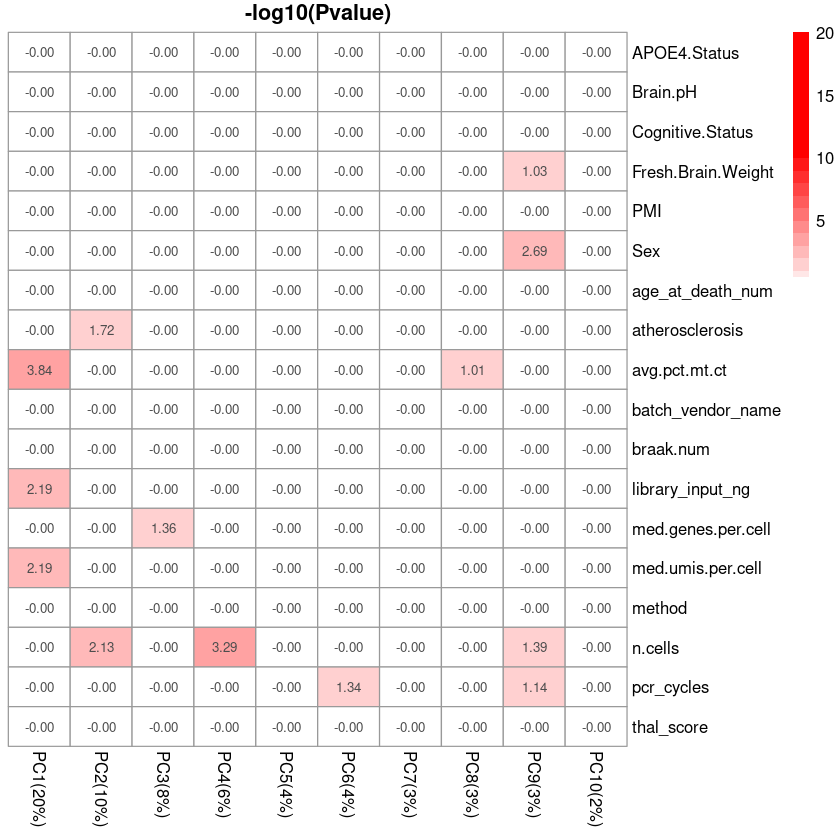

In [27]:
res_cor_pcs<-CorrelCovarPCs(pca,mtdf,
                        sample_col = 'Donor.ID',
               vars_num = covs_to_check$nums,
               vars_cat = covs_to_check$categorical)

plotPvalsHeatMap(res_cor_pcs,p.thr = 0.1,p_col='padj',
                 labels_col =paste0(paste0('PC',1:10),"(",round(pctPC(pca,rngPCs = 1:10)*100,0),"%)") )



%mitochondrial genes, as well as, library input,median umis, pcr_cycles, number of cells and sex are significantly associated with the first PCs.  
%mitochondrial genes are the most strongly assoc with PC1 but was not very visible in the PcaPlot(). We can look at if it is  more visible if we logtransform data 

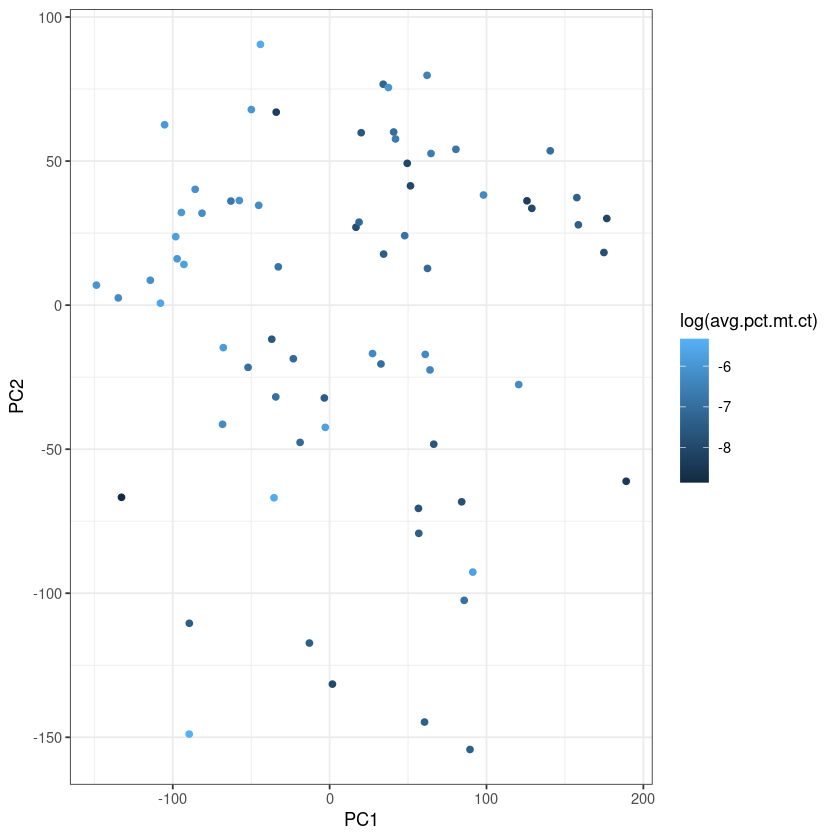

In [32]:
#avg.mt highly assoc with PC1 but not very visible in the PcaPlot(), more visible if we logtransform data?  
mtdf_pcs<-merge(data.table(pca$x,keep.rownames = 'Donor.ID'),mtdf[,.SD,.SDcols=unique(colnames(mtdf))])
ggplot(mtdf_pcs)+geom_point(aes(x=PC1,y=PC2,col=log(avg.pct.mt.ct)))+theme_bw()#yes


Yes, we can see better the association.


### choose which covariates to include 
We finally choose based on these regression analyses which covariates to include.  
We choose here to correct for technical differences : avg.pct.mt.ct, PMI, library input ng, pcr_cycles, n.cells, med.umis.cell
To note, PMI was not associated with the top PCs, but we decided still to incorporate to our model because prior knowledge of the effect/technical bias induced by PMI. 
We also include in our model putative biological confounder : sex, atherosclerosis which was associated with main source of transcriptome variance

In [52]:
design= ~avg.pct.mt.ct+PMI+library_input_ng+pcr_cycles+n.cells+med.umis.per.cell+
 atherosclerosis+Sex+APOE4.Status



## III) run DESEQ2

Before performing the differential expression analysis, we scale the numerical covariates that we decided to include to our model. It helps GLM convergence 

In [41]:
#scale numerical covariates to improve GLM convergence
covs_to_scale<-c('PMI','avg.pct.mt.ct','library_input_ng','pcr_cycles','n.cells','med.umis.per.cell')
mtdf_scaled<-copy(mtdf)
mtdf_scaled[,(covs_to_scale):=lapply(.SD,scale),.SDcols=covs_to_scale]


We then create the DESEQ2 object and Run DESEQ2 model fitting.
DESeq2 uses the raw count matrix to estimate the negative binomial model parameters. it requires thus the **raw/unnormalized count**.
We also include the DESEq2 object the metadata and the chosedesign of our analysis


In [43]:
#run DESEQ2
dds <- DESeqDataSetFromMatrix(matf, 
                              colData = data.frame(mtdf_scaled,row.names="Donor.ID")[colnames(matf),], 
                              design = design)
dds <- DESeq(dds)


  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



Next is to extract from this model the contrast of interest. A good way to do so is to use the `model.matrix()` function. we can explicitly extract the case and control condition to do the contrast. It is also very helpful when studying interaction between 2 covariates
See [this tutorial](https://github.com/tavareshugo/tutorial_DESeq2_contrasts/blob/main/DESeq2_contrasts.md) for more information.

In [48]:
#extract contrast of interest
mod_mat <- model.matrix(design(dds), colData(dds))

apoe4 <- colMeans(mod_mat[dds$APOE4.Status== "Y", ])
apoe3 <- colMeans(mod_mat[dds$APOE4.Status == "N", ])

res <- results(dds,contrast = apoe4-apoe3,alpha = 0.05)

res<-data.table(as.data.frame(res),keep.rownames="gene")

We can then check number of DEGs between APOE4 vs 3 after multiple test correction

In [49]:
res[padj<0.25][order(padj)]


gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
SPDYE2,144.86804,1.0201888,0.22934521,4.448267,8.656580e-06,0.06641223
AC011443.1,23.80129,0.5421646,0.12402433,4.371437,1.234313e-05,0.06641223
USP9Y,644.51785,-0.4709888,0.10654173,-4.420698,9.838257e-06,0.06641223
MT-ND4,1156.77219,0.5582198,0.12159993,4.590626,4.419191e-06,0.06641223
TTTY10,262.92399,-0.4900653,0.11487123,-4.266214,1.988180e-05,0.08155240
MT-CO2,1417.75781,0.4880315,0.11520559,4.236179,2.273554e-05,0.08155240
NR4A3,91.99366,-1.5725117,0.37577708,-4.184693,2.855517e-05,0.08779492
ARFGEF3,662.71953,-0.2880656,0.07005143,-4.112202,3.919039e-05,0.10543195
MT-ND2,653.20048,0.4606627,0.11434056,4.028865,5.604671e-05,0.13402636


We save some useful information about this analysis directly in the differential expression results dataframe, before save the results

In [45]:
#add some annotation to the results
res[,cell_type:="Astro"][,brain_region:='DLPFC']
res[,design:=paste0('~',as.character(design)[2])]
fwrite(res,fp(out,"res_pseudobulkDESeq2_APOE4_vs_3_astro_DLPFC_Cov_sex_atherosclerosis_PMI_ncells_nUmis_LibInput_PCRcycles_avg.mt.csv.gz"))



That's all for the basics of differential expression analysis! 
Choice of covariates to include in the model can be important to good quality results, and should be consider in mind of your biological question. Let's speak about that in next section. 

## Second Design 
we saw previously that Thal score(amyloid) and braak stage (Tau) are associated with APOE4.  
To assess APOE4 effect in earlier stage of the pathology and reduce confounding factor, we will add this time in our model the braak stage.

In [50]:
design= ~avg.pct.mt.ct+PMI+library_input_ng+pcr_cycles+n.cells+med.umis.per.cell+braak.num+atherosclerosis+Sex+APOE4.Status

dds <- DESeqDataSetFromMatrix(matf, 
                              colData = data.frame(mtdf_scaled,row.names="Donor.ID")[colnames(matf),], 
                              design = design)
dds <- DESeq(dds)

  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



In [51]:
#extract contrast of interest and see results
mod_mat <- model.matrix(design(dds), colData(dds))

apoe4 <- colMeans(mod_mat[dds$APOE4.Status== "Y", ])
apoe3 <- colMeans(mod_mat[dds$APOE4.Status == "N", ])

res_braak<- results(dds,contrast = apoe4-apoe3,alpha = 0.05)

res_braak<-data.table(as.data.frame(res_braak),keep.rownames="gene")
res_braak[padj<0.25][order(padj)]


#add some annotation to the results
res_braak[,cell_type:="Astro"][,brain_region:='DLPFC']
res_braak[,design:=paste0('~',as.character(design)[2])]


gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
SPDYE2,144.86804,1.0130407,0.23003608,4.403834,1.063544e-05,0.06097120
AC011443.1,23.80129,0.5503625,0.12268440,4.486002,7.257189e-06,0.06097120
USP9Y,644.51785,-0.4682309,0.10665703,-4.390061,1.133188e-05,0.06097120
MT-ND4,1156.77219,0.5617774,0.12211404,4.600433,4.216143e-06,0.06097120
MT-CO2,1417.75781,0.4909969,0.11581461,4.239508,2.240104e-05,0.09642304
AC104695.4,12.94577,-1.3919036,0.34106521,-4.081048,4.483305e-05,0.11961606
ARFGEF3,662.71953,-0.2876496,0.07030882,-4.091231,4.290899e-05,0.11961606
NR4A3,91.99366,-1.5568959,0.37793079,-4.119526,3.796519e-05,0.11961606
TTTY10,262.92399,-0.4882614,0.12039398,-4.055530,5.002065e-05,0.11961606


In [ ]:
We see that less DEGs pass the threshold of Padj<0.25, but the DEGs are similar. Let's compare gene wides stats with the previous

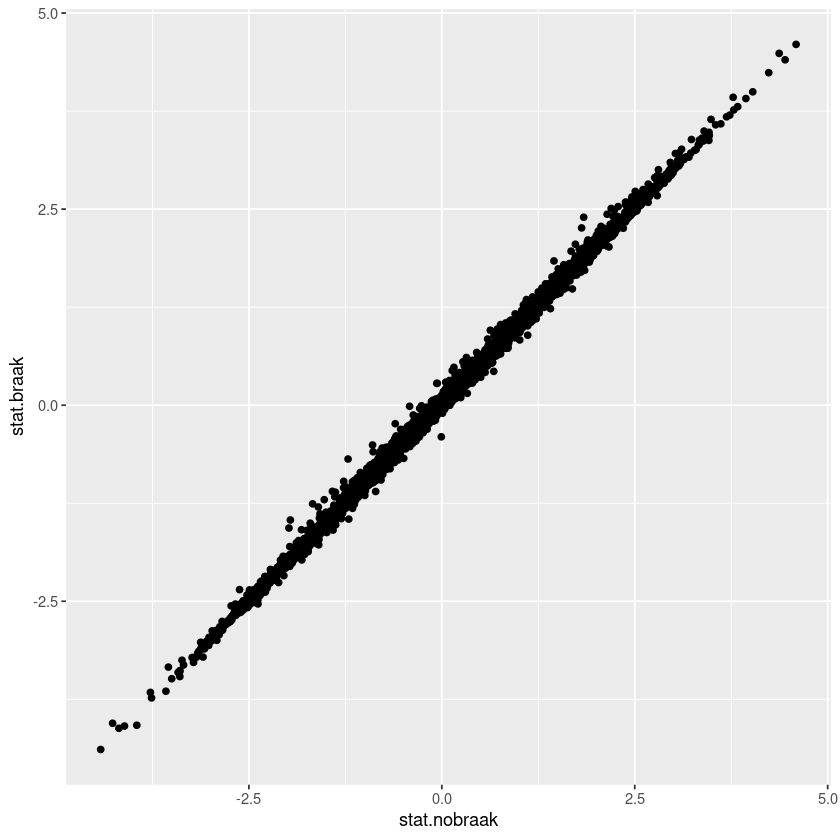

In [56]:
#compa with previous model
res_merge<-merge(res,res_braak,by=c('gene'),suffixes = c('.nobraak','.braak'))
ggplot(res_merge)+geom_point(aes(x=stat.nobraak,y=stat.braak)) 


We see very similar results, but some gene stat are adjusted when modeling for braak stage.
For our biological question, we want effect of APOE4 at 'early' level of the disease, so we will chose to correct for braak stage in final analysis

In [ ]:
fwrite(res_braak,fp(out,"res_pseudobulkDESeq2_Dementia_APOE4_vs_3_astro_DLPFC_Cov_sex_braak_atherosclerosis_PMI_ncells_nUmis_LibInput_PCRcycles_avg.mt.csv.gz"))


So covariates correction can be important to think about it, even if we do not expect major change if the covariate influence on the gene expression variance (PCA analysis) are small. 
We could also have included in our model the first PCs (like the 10 first) to consider them as 'hidden factor'. I encourage you test such analysis and compared the performance on DEGs discovery.

# DESEQ2 in others conditions 

## Within a subpopulation of samples

We choose this time to perform the APOE4 analyis by separating AD and control donors, to assess the different impact of APOE4 at early / late stage of pathology. 

In [ ]:
#do within control, dementia people (no need of braak correction this time)
design= ~avg.pct.mt.ct+PMI+library_input_ng+pcr_cycles+n.cells+med.umis.per.cell+atherosclerosis+Sex+APOE4.Status

for(d in c('Dementia','No dementia')){
  mtdf_scaledf<-mtdf_scaled[Cognitive.Status==d]
  matff<-matf[,mtdf_scaledf$Donor.ID]
  dds <- DESeqDataSetFromMatrix(matff, 
                                colData = data.frame(mtdf_scaledf,row.names="Donor.ID")[colnames(matff),], 
                                design = design)
  dds <- DESeq(dds)
  
  #extract contrast of interest
  mod_mat <- model.matrix(design(dds), colData(dds))
  
  apoe4 <- colMeans(mod_mat[dds$APOE4.Status== "Y", ])
  apoe3 <- colMeans(mod_mat[dds$APOE4.Status == "N", ])
  
  res<- results(dds,contrast = apoe4-apoe3,alpha = 0.05)
  
  res<-data.table(as.data.frame(res),keep.rownames="gene")
  
  #add some annotation to the results
  res[,cell_type:="Astro"][,brain_region:='DLPFC'][,Cognitive.Status:=d]
  res[padj<0.25][order(padj)]
  
  res[,design:=paste0('~',as.character(design)[2])]
  

  fwrite(res,fp(out,paste0("res_pseudobulkDESeq2_",make.names(d),"_APOE4_vs_3_astro_DLPFC_Cov_sex_braak_atherosclerosis_PMI_ncells_nUmis_LibInput_PCRcycles_avg.mt.csv.gz")))
  
}


In [ ]:
## Analysis of the MTG Region
This time we reproduce this same analysis but in the other Brain Region MTG and compared the results.

Donor.ID,Cognitive.Status,outlier.clinical.status,ethnicity,outlier.ethnicity,cell_prop_dev_pc1,outlier.cellprop,n.cells,outlier.n.cells
<chr>,<chr>,<lgl>,<chr>,<lgl>,<dbl>,<lgl>,<int>,<lgl>
H18.30.001,Reference,TRUE,,NA,-1.5053632,FALSE,1,TRUE
H18.30.002,Reference,TRUE,,NA,-0.3199042,FALSE,665,FALSE
H19.30.001,Reference,TRUE,,NA,0.6528876,FALSE,1103,FALSE
H19.30.002,Reference,TRUE,,NA,0.3611166,FALSE,821,FALSE
H20.33.028,Dementia,FALSE,White,FALSE,-3.6546149,TRUE,1886,FALSE
H20.33.029,Dementia,TRUE,Asian,TRUE,0.9616484,FALSE,459,FALSE
H20.33.038,Dementia,FALSE,White,FALSE,-9.0820735,TRUE,1433,FALSE
H21.33.003,No dementia,TRUE,Asian,TRUE,0.8663456,FALSE,1127,FALSE
H21.33.020,Dementia,FALSE,White,FALSE,-6.9302496,TRUE,1300,FALSE


77  samples kept after QC
21407  genes kept after QC


factor,p,beta,R2
<chr>,<dbl>,<dbl>,<dbl>
braak.num,1.895604e-02,0.1110028,0.05884767
thal_score,2.709903e-05,0.1314433,0.19997311


Calculating cell attributes from input UMI matrix: log_umi

Variance stabilizing transformation of count matrix of size 21407 by 77

Model formula is y ~ log_umi

Get Negative Binomial regression parameters per gene

Using 2000 genes, 77 cells



  |======================================================================| 100%


Found 1 outliers - those will be ignored in fitting/regularization step


Second step: Get residuals using fitted parameters for 21407 genes



  |======================================================================| 100%


Calculating gene attributes

Wall clock passed: Time difference of 3.420177 secs

removing 0 features (21407remaining) because missing value or without variance



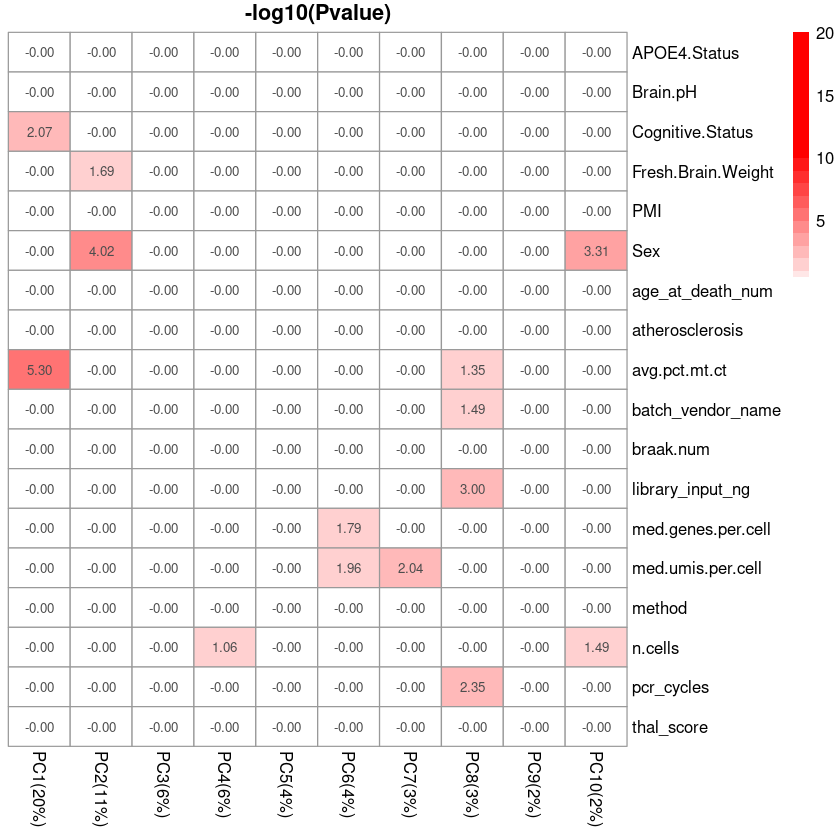

In [58]:
####Same analysis but for MTG Reggion#####
#load data 
pseudo_count<-fread('../outputs/01-SEAAD_data/MTG/pseudobulk_main_cell_type/Astro.csv.gz')

mat<-as.matrix(data.frame(pseudo_count,row.names = 'gene_id'))

mtd<-fread('../outputs/01-SEAAD_data/MTG/pseudobulk_main_cell_type/Astro_metadata.csv.gz')

# I) QC ####
#remove samples if flagged as outliers (See QC script) 
#here, all donors with clinical or cellular abnormalities are exclude, and if the pseudobulk come from n.cell<50
mtd[(outlier)][,.(Donor.ID,Cognitive.Status,outlier.clinical.status,ethnicity,outlier.ethnicity,cell_prop_dev_pc1,outlier.cellprop,n.cells,outlier.n.cells)]
mtdf<-mtd[!(outlier|outlier.n.cells)]
cat(length(to_keep),' samples kept after QC\n')

to_keep<-mtdf$Donor.ID 
mat<-mat[,to_keep]

#Filter lowly expressed genes
#genes signicantly express (thr= 1CPM) in less than 10% of sample are removed
isexpr <- rowSums(cpm(mat)>1) >= 0.1 * ncol(mat)
cat(sum(isexpr),' genes kept after QC\n')

matf <- mat[isexpr,]


#II) influence of covariates####
##first have a look on corelation between our factor of interest (here apoe4) and other covariates
#let's first transform as numerical all covariates which can be
mtdf[,braak.num:=as.numeric(as.factor(Braak))]
mtdf[,thal_score:=as.numeric(factor(Thal))]
mtdf[,atherosclerosis:=as.numeric(factor(Atherosclerosis,levels = c('None','Mild','Moderate','Severe')))]

#also levels correctly categorical factor with the good reference
mtdf[,Cognitive.Status:=factor(Cognitive.Status,levels = c('No dementia','Dementia'))] #reference is 'No dementia', so put in first positon,
mtdf[,APOE4.Status:=factor(APOE4.Status,levels = c('N','Y'))]
mtdf[,Sex:=factor(Sex,levels = c('Female','Male'))]

covs_to_check<-list(categorical=c('batch_vendor_name','method',
                                  'Cognitive.Status','Sex','APOE4.Status'),
                    nums=c('avg.pct.mt.ct','n.cells','med.umis.per.cell',
                           'med.genes.per.cell','library_input_ng','pcr_cycles',
                           'PMI','age_at_death_num','Brain.pH','braak.num',
                           'Fresh.Brain.Weight','thal_score','atherosclerosis'))

factor_of_int<-'APOE4.Status'

res_cor_fctr<-rbindlist(lapply(setdiff(covs_to_check$nums,factor_of_int), function(f){
  mod<-lm(unlist(mtdf[,lapply(.SD, as.numeric),.SDcols=factor_of_int])~unlist(mtdf[,..f]))
  summstats<-summary(mod)
  data.table(factor=f,
             p=summstats$coefficients[2,4],
             beta=summstats$coefficients[2,1],
             R2=summstats$adj.r.squared)
}))
res_cor_fctr[p<0.05] #asso with braak.num, thal score, which is expected


#we then perform a PCA to assess influence of each covariates in the main transcriptome variance
#based on that, we could choose for which technical covariates or putative confounding bioligical factor to correct for
#scale the data using a variance stabilizing transformation (vst)to UMI count data using a regularized Negative Binomial regression model.
#plan(strategy = "multicore", workers = 4)

matf_norm_scaled <- sctransform::vst(matf)$y #y is pearson residual, so already normalized data


pca<-RunPca(matf_norm_scaled,scale = F,center = F)


res_cor_pcs<-CorrelCovarPCs(pca,mtdf,
                            sample_col = 'Donor.ID',
                            vars_num = covs_to_check$nums,
                            vars_cat = covs_to_check$categorical)

plotPvalsHeatMap(res_cor_pcs,p.thr = 0.1,p_col='padj',
                 labels_col =paste0(paste0('PC',1:10),"(",round(pctPC(pca,rngPCs = 1:10)*100,0),"%)") )

#

Interestingly, this time Cognitive status is associated with main source of variance (PC1), meaning that AD are more influence in MTG astrocyte than in DLPFC astrocyte.  

Could it because MTG astrocyte are still 'reactive' to AD spreading in MTG while DLPFC astrocytes are already in an exhausted state, or in a simlar state at in both dementia and cognitively normal individuals of this age ?


In [ ]:
## choose covariates to include
#choose to correct for putative technical differences : avg.pct.mt.ct, PMI, library input ng, pcr_cycles, n.cells, med.umis.cell
#choose to correct for putative biological confounder : sex, atherosclerosis, braak
design= ~avg.pct.mt.ct+PMI+library_input_ng+pcr_cycles+n.cells+med.umis.per.cell+braak.num+atherosclerosis+Sex+APOE4.Status

#scale numerical covariates to improve GLM convergence
covs_to_scale<-c('PMI','avg.pct.mt.ct','library_input_ng','pcr_cycles','n.cells','med.umis.per.cell')
mtdf_scaled<-copy(mtdf)
mtdf_scaled[,(covs_to_scale):=lapply(.SD,scale),.SDcols=covs_to_scale]

#III) run DESEQ2 #### 
dds <- DESeqDataSetFromMatrix(matf, 
                              colData = data.frame(mtdf_scaled,row.names="Donor.ID")[colnames(matf),], 
                              design = design)
dds <- DESeq(dds)

#extract contrast of interest
mod_mat <- model.matrix(design(dds), colData(dds))

apoe4 <- colMeans(mod_mat[dds$APOE4.Status== "Y", ])
apoe3 <- colMeans(mod_mat[dds$APOE4.Status == "N", ])

res <- results(dds,contrast = apoe4-apoe3,alpha = 0.05)

res<-data.table(as.data.frame(res),keep.rownames="gene")

#add some annotation to the results
res[,cell_type:="Astro"][,brain_region:='MTG']
res[padj<0.25][order(padj)]

res[,design:=paste0('~',as.character(design)[2])]

#fwrite(res,fp(out,"res_pseudobulkDESeq2_APOE4_vs_3_astro_MTG_Cov_sex_braak_atherosclerosis_PMI_ncells_nUmis_LibInput_PCRcycles_avg.mt.csv.gz"))


# DESEQ2 in others conditions ###
#do within control or dementia people (wihtout braak correction this time)
design= ~avg.pct.mt.ct+PMI+library_input_ng+pcr_cycles+n.cells+med.umis.per.cell+atherosclerosis+Sex+APOE4.Status

for(d in c('Dementia','No dementia')){
  mtdf_scaledf<-mtdf_scaled[Cognitive.Status==d]
  matff<-matf[,mtdf_scaledf$Donor.ID]
  dds <- DESeqDataSetFromMatrix(matff, 
                                colData = data.frame(mtdf_scaledf,row.names="Donor.ID")[colnames(matff),], 
                                design = design)
  dds <- DESeq(dds)
  
  #extract contrast of interest
  mod_mat <- model.matrix(design(dds), colData(dds))
  
  apoe4 <- colMeans(mod_mat[dds$APOE4.Status== "Y", ])
  apoe3 <- colMeans(mod_mat[dds$APOE4.Status == "N", ])
  
  res<- results(dds,contrast = apoe4-apoe3,alpha = 0.05)
  
  res<-data.table(as.data.frame(res),keep.rownames="gene")
  
  #add some annotation to the results
  res[,cell_type:="Astro"][,brain_region:='MTG'][,Cognitive.Status:=d]
  res[padj<0.25][order(padj)]
  
  res[,design:=paste0('~',as.character(design)[2])]
  
  
 # fwrite(res,fp(out,paste0("res_pseudobulkDESeq2_",make.names(d),"_APOE4_vs_3_astro_MTG_Cov_sex_braak_atherosclerosis_PMI_ncells_nUmis_LibInput_PCRcycles_avg.mt.csv.gz")))
  
}


Compare now the results for the 2 brain regions.
In the Overall population :


Call:
lm(formula = stat.DLPFC ~ stat.MTG)

Residuals:
    Min      1Q  Median      3Q     Max 
-5.0756 -0.7392 -0.0372  0.7200  4.1828 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.020025   0.007339   2.728  0.00637 ** 
stat.MTG    0.318369   0.007804  40.797  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.062 on 21001 degrees of freedom
Multiple R-squared:  0.07343,	Adjusted R-squared:  0.07339 
F-statistic:  1664 on 1 and 21001 DF,  p-value: < 2.2e-16


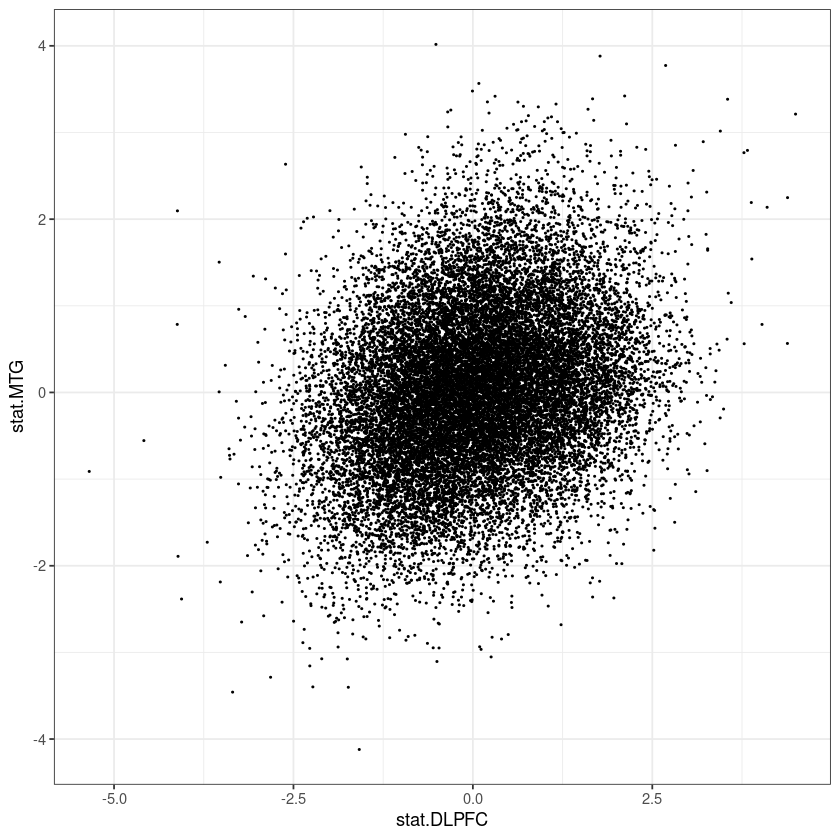

In [59]:
#Comparison of Brain Region ####
#compare DLPFC and MTG
#full data
res_merge<-merge(fread(fp(out,"res_pseudobulkDESeq2_APOE4_vs_3_astro_DLPFC_Cov_sex_braak_atherosclerosis_PMI_ncells_nUmis_LibInput_PCRcycles_avg.mt.csv.gz")),
                       fread(fp(out,"res_pseudobulkDESeq2_APOE4_vs_3_astro_MTG_Cov_sex_braak_atherosclerosis_PMI_ncells_nUmis_LibInput_PCRcycles_avg.mt.csv.gz")),
                 by=c('gene','cell_type'),suffixes = c(".DLPFC", ".MTG"))


ggplot(res_merge)+geom_point(aes(x=stat.DLPFC,y=stat.MTG),size=0.2) +theme_bw() 

res_merge[,summary(lm(stat.DLPFC~stat.MTG))]


In [ ]:
correl but R2 low. 

When analyzing separately AD and Control:

Cognitive.Status,V1,R2
<chr>,<dbl>,<dbl>
Dementia,0.3609409,0.3609409
No dementia,0.2284995,0.2284995


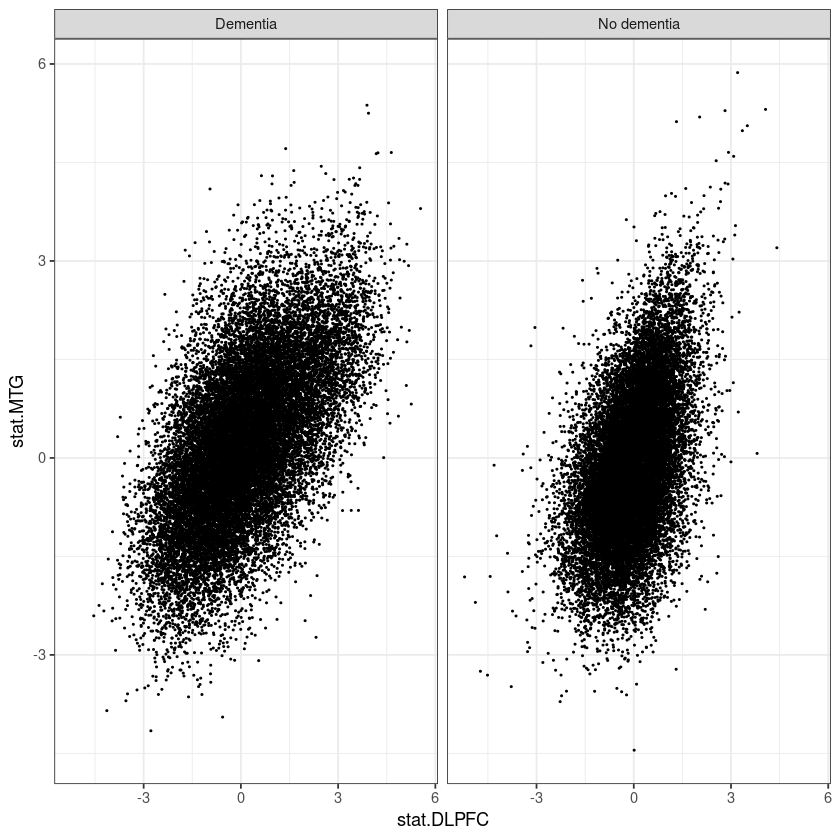

In [61]:

#by cognitive status
res_merge<-merge(rbind(fread(fp(out,"res_pseudobulkDESeq2_Dementia_APOE4_vs_3_astro_DLPFC_Cov_sex_braak_atherosclerosis_PMI_ncells_nUmis_LibInput_PCRcycles_avg.mt.csv.gz")),
                       fread(fp(out,"res_pseudobulkDESeq2_No.dementia_APOE4_vs_3_astro_DLPFC_Cov_sex_braak_atherosclerosis_PMI_ncells_nUmis_LibInput_PCRcycles_avg.mt.csv.gz"))),
                 rbind(fread(fp(out,"res_pseudobulkDESeq2_Dementia_APOE4_vs_3_astro_MTG_Cov_sex_braak_atherosclerosis_PMI_ncells_nUmis_LibInput_PCRcycles_avg.mt.csv.gz")),
                       fread(fp(out,"res_pseudobulkDESeq2_No.dementia_APOE4_vs_3_astro_MTG_Cov_sex_braak_atherosclerosis_PMI_ncells_nUmis_LibInput_PCRcycles_avg.mt.csv.gz"))),
                 by=c('gene','cell_type','Cognitive.Status'),suffixes = c(".DLPFC", ".MTG"))


ggplot(res_merge)+geom_point(aes(x=stat.DLPFC,y=stat.MTG),size=0.2) +theme_bw() +facet_wrap('Cognitive.Status')

R2<-res_merge[,summary(lm(stat.DLPFC~stat.MTG))$adj.r.squared,by='Cognitive.Status']
R2[,R2:=V1]
R2




There is a Bigger MTG/DLPFC correlation when we perform the analysis when individuals are stratified by cognitive status.  

The correlation is even greater in Dementia people.  
Regarding that dementia effect on astrocyte is visible mainly in MTG (based on PCA analysis), and that MTG are affected by the disease at later stage, MTG brain environment should look more to DLPFC  at this stage of the disease. Then, this could explain why the APOE4 effect on astrocyte is more similar between the 2 brain region at this stage of the pathology
